# Trapping experiment June 2026

## Current on the extraction electrodes with Field emission tip on
Uses a Keithley multimeter to measure the current flow through the extraction electrodes 

In [1]:
import pyvisa as visa
from time import sleep
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from pathlib import Path
from edes.modules.detection.detection_utils import plot, plot_ax, plot_ax_errbar,
                                                    plot_errbar, big_plt_font
big_plt_font()
rm = visa.ResourceManager()
instruments = rm.list_resources()
usb = list(filter(lambda x: 'USB' in x, instruments))

In [89]:
keithley = rm.open_resource("USB0::1510::8448::1243106::0::INSTR")

# SSA = rm.open_resource(usb[1])
print(keithley.query("*IDN?"))
keithley.write("*rst; status:preset; *cls")

KEITHLEY INSTRUMENTS INC.,MODEL 2100,1,01.07-01-01


27

Can use this function to basically read the voltage on Agilent, and current it to current based on the 200Mohm resistance. Note that 200MOhm cannot be directly measured on the meter, so you have to measure one at a time to be 100Mohm and infer. Meter is limited at 100MOhm, and will be ovld otherwise.

In [87]:
def measure_IV(R=100e6): 
    V = float(keithley.query("MEAS:VOLT:DC?"))
    I = V/R
    return I, V

Here we use the Rigol power supply unit to control the high voltage power supply to turn on the tip. **Make sure to turn on the output of the power supply physically before running the code below**

In [7]:
import pyvisa as visa
from time import sleep
import matplotlib.pyplot as plt
import numpy as np
from edes.modules.power_supply import PSU_utils 
device_lib = PSU_utils.load_device_lib()
PSU = device_lib.PS350_viaDP832A('USB0::6833::3601::DP8B260200018::0::INSTR')

Rigol DP832A found: RIGOL TECHNOLOGIES,DP832A,DP8B260200018,00.01.19


Some ramp function here to ramp down from initial voltage V0 or ramp up to Vf from V0

In [8]:
def ramp_down_tip(V0): 
    V = V0
    while V > 0: 
        PSU.set_voltage(max(V - 200, 0))
        V = V - 200 
    PSU.rigol.output_off(1)

def ramp_up_tip(Vf, V0): 
    PSU.rigol.output_on(1)
    V = V0
    while V < Vf: 
        PSU.set_voltage(max(V + 200, 0))
        V = V + 200 

In [229]:
ramp_down_tip(2100)

Can set a voltage, then measure I, V across the resistor. Make sure to connect the resistor physically if wanting to measure the current and voltage.

In [11]:
PSU.set_voltage(500)
sleep(5)
I= measure_I() 
I

-2.12305744e-07

In [224]:
ramp_up_tip(2000, 100)

In [225]:
PSU.set_voltage(2200)

Can scan the voltage here

In [115]:
# I_avg = 0
I_list = [] 
n_avg = 100
for i in range(n_avg):
    I, V = measure_IV()
    I_list.append(I)
    I_array = np.array(I_list)
-np.mean(I_array)*1e12, np.std(I_array)*1e12

(np.float64(10.262926088), np.float64(0.9533819230039997))

In [203]:
from tqdm import tqdm
all_I = [] 
std_I = []
all_I_raw = []
all_V = np.arange(800, 2000, 100)
n_avg = 100
for V in tqdm(all_V): 
    PSU.set_voltage(V) 
    sleep(2) 
    I_list = []
    for i in range(n_avg):
        I, V = measure_IV()
        I_list.append(I)
    I_array = np.array(I_list)
    all_I_raw.append(I_array)
    all_I.append(np.mean(I_array))
    std_I.append(np.std(I_array))
prefix = 'tl5-rf'    
folder_path = f'/home/electron/data/cooldown_06012026/FE-tip'
target_dir = Path(folder_path)
target_dir.mkdir(parents=True, exist_ok=True)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
file_name = f"{prefix}_{timestamp}.npz"
file_path = target_dir / file_name
np.savez(file_path, all_I=all_I,
         std_I=std_I, I_raw=all_I_raw)
ramp_down_tip(2000)

100%|███████████████████████████████████████████| 12/12 [00:52<00:00,  4.36s/it]


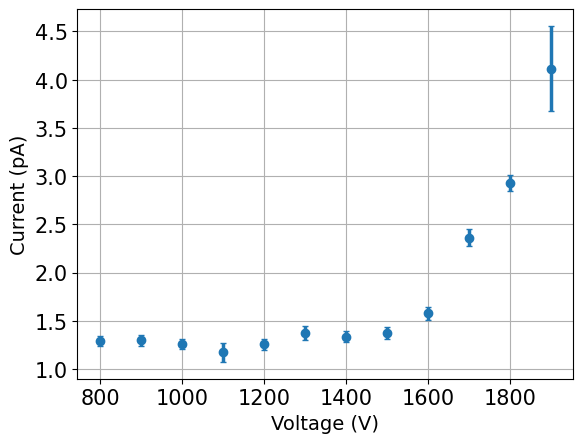

In [204]:
plot_errbar(all_V, -np.array(all_I)*1e12, yerr=np.array(std_I)*1e12, fmt='.', xlabel='Voltage (V)', ylabel='Current (pA)')
# plt.yscale('log')

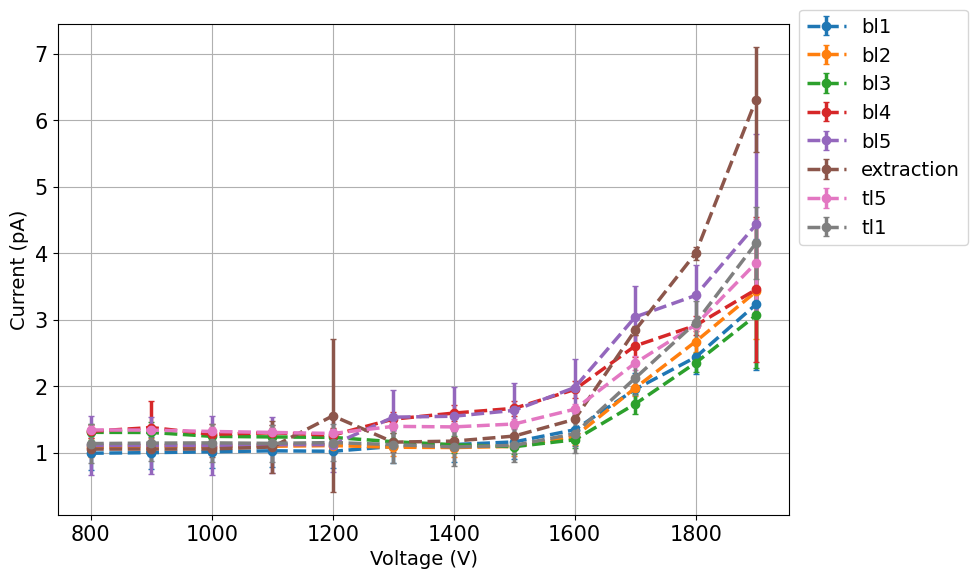

In [176]:
data = ['data/cooldown_06012026/FE-tip/bl1_20260602_180339.npz', 
        'data/cooldown_06012026/FE-tip/bl2_20260602_181355.npz', 
        'data/cooldown_06012026/FE-tip/bl3_20260602_170413.npz', 
        'data/cooldown_06012026/FE-tip/bl4_20260602_170703.npz', 
        'data/cooldown_06012026/FE-tip/bl5_20260602_175423.npz', 
        'data/cooldown_06012026/FE-tip/et_20260602_170210.npz',
        'data/cooldown_06012026/FE-tip/tl5_20260602_181801.npz', 
        'data/cooldown_06012026/FE-tip/tl1_20260602_182429.npz'] 
labels = ['bl1', 'bl2', 'bl3', 'bl4', 'bl5', 'extraction', 'tl5', 'tl1'] 
fig, ax = plt.subplots(figsize=(10,6)) 
for i in range(len(data)): 
    file = np.load(f'/home/electron/{data[i]}') 
    std_I = file['std_I'] 
    all_I = file['all_I']
    plot_ax_errbar(ax, all_V, -np.array(all_I)*1e12, yerr=np.array(std_I)*1e12, 
                fmt='.--', label=labels[i],
                xlabel='Voltage (V)', ylabel='Current (pA)')
plt.legend(bbox_to_anchor=(1,1.05))
plt.tight_layout() 
plt.show()

## Valon control

In [177]:
import pyvisa as visa
from qcodes_contrib_drivers.drivers.Valon.Valon_5015 import Valon5015
import time
import matplotlib.pyplot as plt13
import numpy as np
from tqdm import trange, tqdm
from edes.modules.detection.detection_utils import plot, plot_ax, big_plt_font
from datetime import datetime
from edes.modules.trap_drive.utils import beep, V_to_P, P_to_V

big_plt_font()
rm = visa.ResourceManager()
# SSA = rm.open_resource('TCPIP::192.168.169.161::INSTR')
# print(SSA.query("*IDN?"))

addr = 'ASRL/dev/ttyUSB0::INSTR'
valon = Valon5015(name="Valon", address=addr)
valon.frequency(1472114285)
valon.offset(0)
valon.power(0)
valon.modulation_db(0)
valon.modulation_frequency(1)
valon.low_power_mode_enabled(True)
valon.buffer_amplifiers_enabled(False)
status = valon.status()
print(status)

base_dir = '/home/electron/data/experiment_05282026'

-->amf 1
AMF 0.001 kHz
-->pdn 1
PDN 1;
-->oen 0
OEN 0;
-->stat
Valon Technology, 5019, 12202687, R5  version 1.2c   Build: Aug  8 2022  01:10:47
      VBAT = 1436   6.941 V
      UPTS = 1738    19.5 C
   PA TEMP = 1079    24.0 C
       +5V = 3061   4.932 V
       -5V = 1491  -5.116 V


Set power here, units in dBm

In [228]:
valon.power(11)

To turn on, change ON to be 1

In [230]:
ON = 0
valon.buffer_amplifiers_enabled(bool(ON))

Can scan the power, here it is scanning from 6dBm to 15dBm with step of 0.1dBm

In [226]:
for P in np.arange(6, 13, 0.1): 
    valon.power(P) 
    print(P)
    sleep(1)

6.0
6.1
6.199999999999999
6.299999999999999
6.399999999999999
6.499999999999998
6.599999999999998
6.6999999999999975
6.799999999999997
6.899999999999997
6.9999999999999964
7.099999999999996
7.199999999999996
7.299999999999995
7.399999999999995
7.499999999999995
7.599999999999994
7.699999999999994
7.799999999999994
7.899999999999993
7.999999999999993
8.099999999999993
8.199999999999992
8.299999999999992
8.399999999999991
8.499999999999991
8.59999999999999
8.69999999999999
8.79999999999999
8.89999999999999
8.99999999999999
9.099999999999989
9.199999999999989
9.299999999999988
9.399999999999988
9.499999999999988
9.599999999999987
9.699999999999987
9.799999999999986
9.899999999999986
9.999999999999986
10.099999999999985
10.199999999999985
10.299999999999985
10.399999999999984
10.499999999999984
10.599999999999984
10.699999999999983
10.799999999999983
10.899999999999983
10.999999999999982
11.099999999999982
11.199999999999982
11.299999999999981
11.39999999999998
11.49999999999998
11.5999999

Set frequency using this line

In [214]:
valon.frequency(1472114285)

## Spectrum analyzer

In [209]:
SSA = rm.open_resource('TCPIP::192.168.169.161::INSTR')

In [231]:
freq_center = 198.016 # MHz
freq_span = 0 # MHz
RBW_AUTO = 0 #1-ON, 0-OFF
VBW_AUTO = 1 #1-ON, 0-OFF
SWT_AUTO = 1 #1-ON, 0-OFF
VBW_RBW_RAT = 10 
RBW = 0.1 #kHz
VBW = 0.1 #kHz
SWT = 1 #ms
N_AVG = 32

# Configure frequency
SSA.write("SENS:FREQ:CENT " + str(freq_center) + " MHz")
SSA.write("SENS:FREQ:SPAN " + str(freq_span) + " MHz")

# Configure bandwidths and sweep time
SSA.write("SENS:BWID:AUTO " + str(RBW_AUTO))
SSA.write("SENS:BWID:VID:AUTO " + str(VBW_AUTO))
SSA.write("SENS:SWE:TIME:AUTO " + str(SWT_AUTO))
SSA.write("SENS:BWID:VID " + str(VBW) + " kHz")
SSA.write("SENS:BWID " + str(RBW) + " kHz")
SSA.write("SENS:BWID:VID:RAT " + str(VBW_RBW_RAT))
SSA.write("SENS:SWE:TIME " + str(SWT) + " ms")

# Set sweep mode to FFT
SSA.write(":SWEep:MODE FFT")

17

Trying some code to scan and average the spectrum. This code takes a trace during each repetition, and then collects the whole data and do average.

In [217]:
T_load = 5 
T_idle = 1
T_wait = 2 
T_SSA_buffer = 2
V_on = 1900
V_off = 1300

N_rep = 32 

PSU.set_voltage(V_off)
T_total = T_load + T_wait + T_idle + T_SSA_buffer
T_exp = T_load + T_wait + T_idle
t_load_start = T_idle
t_load_end = t_load_start + T_load
SSA.write(f"SENS:SWE:TIME {T_total} s")
all_data = []
for i in tqdm(range(N_rep)): 
    SSA.write(":AVERage:TRAC1:CLEar")
    sleep(T_idle) 
    PSU.set_voltage(V_on)
    sleep(T_load)
    PSU.set_voltage(V_off)
    for P in np.arange(5, 10, 0.1): 
        valon.power(P) 
        # sleep(1)
    # sleep(T_wait)
    valon.power(5)
    data_str_C = SSA.query(":TRACe1:DATA?")
    sleep(T_SSA_buffer)
    data_arr_C = np.array([float(val) for val in data_str_C.split(',')]) 
    all_data.append(data_arr_C)
PSU.set_voltage(1000)
beep()

 94%|████████████████████████████████████████▎  | 30/32 [04:31<00:18,  9.08s/it]/home/electron/miniconda3/envs/e/lib/python3.10/site-packages/qcodes_contrib_drivers/drivers/Valon/Valon_5015.py:104: UserWarning: read string doesn't end with termination characters
  return [self.visa_handle.read() for _ in range(ltr)]
100%|███████████████████████████████████████████| 32/32 [04:49<00:00,  9.06s/it]


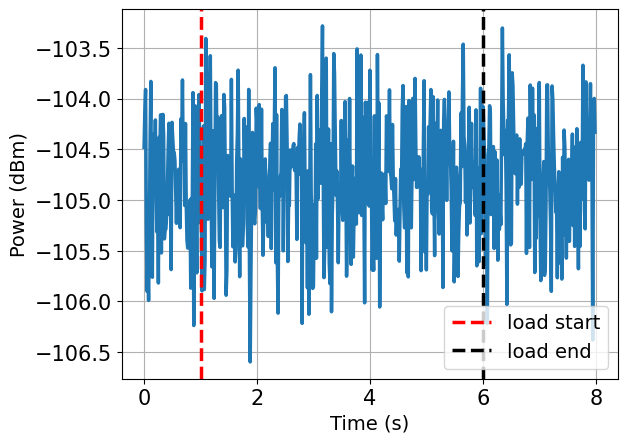

In [218]:
num_points = len(all_data[0])
t_axis = np.linspace(0, T_total, num_points) 
idx = np.where(t_axis < T_exp)
plot(t_axis[idx], np.mean(all_data, axis=0)[idx], xlabel='Time (s)', ylabel='Power (dBm)')
plt.axvline(t_load_start, linestyle='--', color='r', label='load start') 
plt.axvline(t_load_end, linestyle='--', color='k', label='load end')
plt.legend()
plt.show()

100%|███████████████████████████████████████████| 16/16 [02:56<00:00, 11.03s/it]


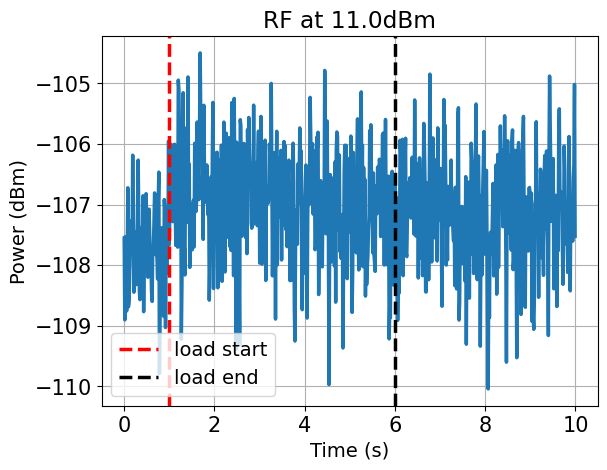

100%|███████████████████████████████████████████| 16/16 [02:56<00:00, 11.03s/it]


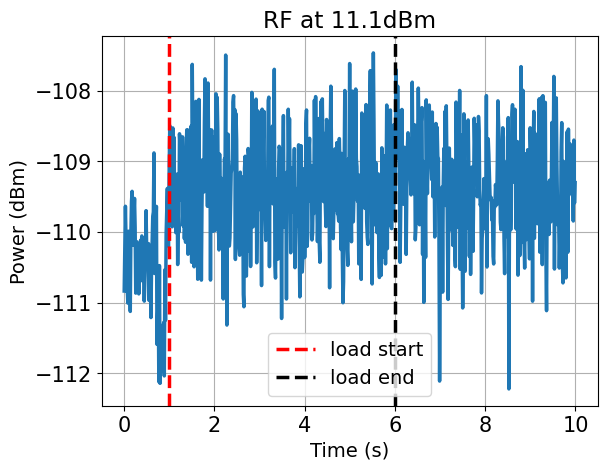

100%|███████████████████████████████████████████| 16/16 [02:56<00:00, 11.03s/it]


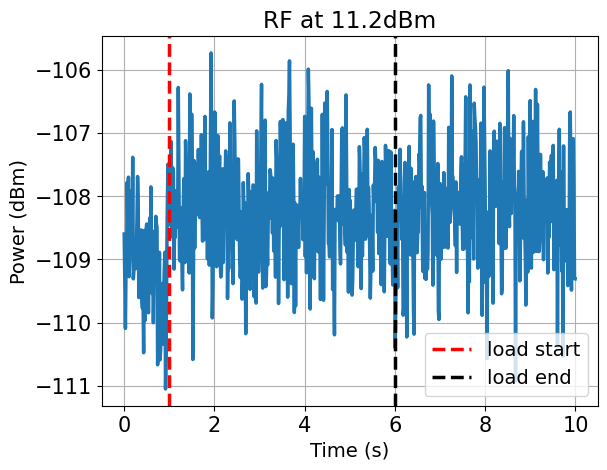

  6%|██▊                                         | 1/16 [00:16<04:11, 16.80s/it]


KeyboardInterrupt: 

In [241]:
T_load = 5 
T_wait = 5 
T_SSA_buffer = 0.1
V_on = 2500
V_off = 1300

N_rep = 16 

PSU.set_voltage(V_off)
T_total = T_load + T_wait + T_SSA_buffer
T_exp = T_load + T_wait
t_load_start = T_idle
t_load_end = t_load_start + T_load
SSA.write(f"SENS:SWE:TIME {T_total} s")

for P in np.arange(11, 11.5, 0.1):
    all_data = []
    valon.power(P)
    
    for j in tqdm(range(N_rep)): 
        valon.buffer_amplifiers_enabled(bool(1))
        SSA.write(":AVERage:TRAC1:CLEar")
        PSU.set_voltage(V_on)
        sleep(T_load)
        PSU.set_voltage(V_off)
        sleep(T_wait)
        data_str_C = SSA.query(":TRACe1:DATA?")
        data_arr_C = np.array([float(val) for val in data_str_C.split(',')]) 
        all_data.append(data_arr_C)
        valon.buffer_amplifiers_enabled(bool(0))
        sleep(1)

    num_points = len(all_data[0])
    t_axis = np.linspace(0, T_total, num_points) 
    idx = np.where(t_axis < T_exp)
    plot(t_axis[idx], np.mean(all_data, axis=0)[idx], xlabel='Time (s)', 
         ylabel='Power (dBm)', title=f'RF at {P}dBm')
    plt.axvline(t_load_start, linestyle='--', color='r', label='load start') 
    plt.axvline(t_load_end, linestyle='--', color='k', label='load end')
    plt.legend()
    plt.show()
PSU.set_voltage(1000)
beep()

In [238]:
valon.buffer_amplifiers_enabled(bool(1))

100%|███████████████████████████████████████████| 64/64 [07:29<00:00,  7.03s/it]


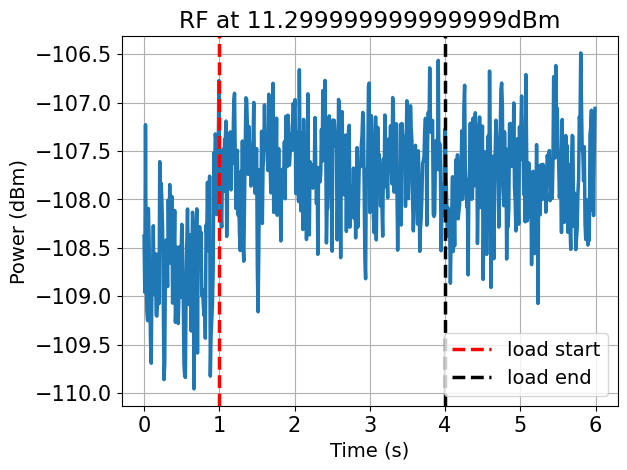

In [242]:
T_load = 3 
T_wait = 3 
T_SSA_buffer = 1.1
V_on = 2500
V_off = 1300

N_rep = 64 

PSU.set_voltage(V_off)
T_total = T_load + T_wait + T_SSA_buffer
T_exp = T_load + T_wait
t_load_start = T_idle
t_load_end = t_load_start + T_load
SSA.write(f"SENS:SWE:TIME {T_total} s")


all_data = []
valon.power(11)

for j in tqdm(range(N_rep)): 
    valon.buffer_amplifiers_enabled(bool(1))
    SSA.write(":AVERage:TRAC1:CLEar")
    PSU.set_voltage(V_on)
    sleep(T_load)
    PSU.set_voltage(V_off)
    sleep(T_wait)
    data_str_C = SSA.query(":TRACe1:DATA?")
    data_arr_C = np.array([float(val) for val in data_str_C.split(',')]) 
    all_data.append(data_arr_C)
    valon.buffer_amplifiers_enabled(bool(0))
    sleep(1)

num_points = len(all_data[0])
t_axis = np.linspace(0, T_total, num_points) 
idx = np.where(t_axis < T_exp)
plot(t_axis[idx], np.mean(all_data, axis=0)[idx], xlabel='Time (s)', 
     ylabel='Power (dBm)', title=f'RF at {P}dBm')
plt.axvline(t_load_start, linestyle='--', color='r', label='load start') 
plt.axvline(t_load_end, linestyle='--', color='k', label='load end')
plt.legend()
plt.show()
PSU.set_voltage(1000)
beep()

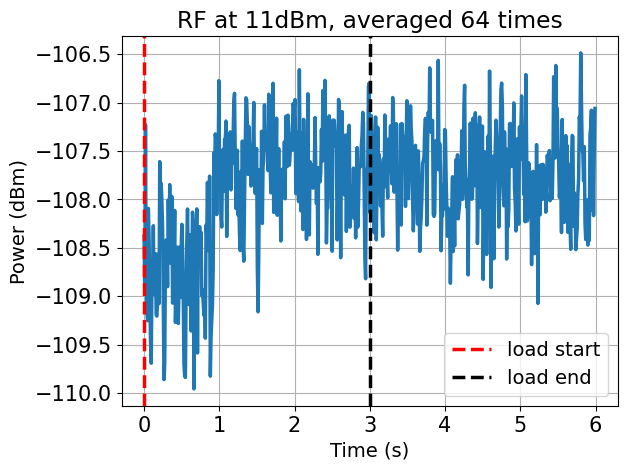

In [243]:
T_idle = 0
t_load_start = T_idle
t_load_end = t_load_start + T_load
num_points = len(all_data[0])
t_axis = np.linspace(0, T_total, num_points) 
idx = np.where(t_axis < T_exp)
plot(t_axis[idx], np.mean(all_data, axis=0)[idx], xlabel='Time (s)', 
     ylabel='Power (dBm)', title=f'RF at 11dBm, averaged 64 times')
plt.axvline(t_load_start, linestyle='--', color='r', label='load start') 
plt.axvline(t_load_end, linestyle='--', color='k', label='load end')
plt.legend()
plt.show()

In [244]:
T_idle = 1
T_load = 2 
T_wait = 2 
T_RF_buffer = 1
T_SSA_buffer = 0.1
V_on = 2500
V_off = 1300

N_rep = 32 

PSU.set_voltage(V_off)
T_total = T_idle + T_load + T_wait + T_SSA_buffer + T_RF_buffer
T_exp = T_load + T_wait + T_idle + T_RF_buffer
t_load_start = T_idle
t_load_end = t_load_start + T_load
t_RF_on = 0 
t_RF_off = t_load_end + T_wait
SSA.write(f"SENS:SWE:TIME {T_total} s")


all_data = []
valon.power(11)

for j in tqdm(range(N_rep)): 
    valon.buffer_amplifiers_enabled(bool(1))
    SSA.write(":AVERage:TRAC1:CLEar")
    sleep(T_idle)
    PSU.set_voltage(V_on)
    sleep(T_load)
    PSU.set_voltage(V_off)
    sleep(T_wait)
    valon.buffer_amplifiers_enabled(bool(0))
    sleep(T_RF_buffer)
    data_str_C = SSA.query(":TRACe1:DATA?")
    data_arr_C = np.array([float(val) for val in data_str_C.split(',')]) 
    all_data.append(data_arr_C)

100%|███████████████████████████████████████████| 32/32 [03:12<00:00,  6.03s/it]


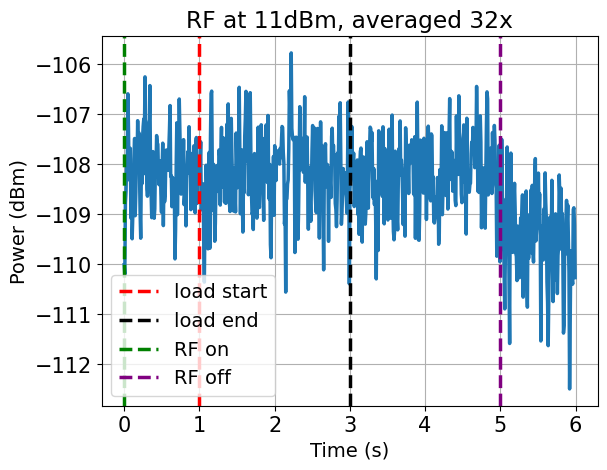

In [245]:
num_points = len(all_data[0])
t_axis = np.linspace(0, T_total, num_points) 
idx = np.where(t_axis < T_exp)
plot(t_axis[idx], np.mean(all_data, axis=0)[idx], xlabel='Time (s)', 
     ylabel='Power (dBm)', title=f'RF at 11dBm, averaged 32x')
plt.axvline(t_load_start, linestyle='--', color='r', label='load start') 
plt.axvline(t_load_end, linestyle='--', color='k', label='load end')
plt.axvline(t_RF_on, linestyle='--', color='g', label='RF on') 
plt.axvline(t_RF_off, linestyle='--', color='purple', label='RF off')
plt.legend()
plt.show()
PSU.set_voltage(1000)
beep()

In [247]:
ramp_down_tip(1000)

In [252]:
T_idle = 1
T_load = 0 
T_wait = 2 
T_RF_buffer = 1
T_SSA_buffer = 0.1
V_on = 2500
V_off = 1300

N_rep = 32 

PSU.output_off()
T_total = T_idle + T_load + T_wait + T_SSA_buffer + T_RF_buffer
T_exp = T_load + T_wait + T_idle + T_RF_buffer
t_load_start = T_idle
t_load_end = t_load_start + T_load
t_RF_on = 0 
t_RF_off = t_load_end + T_wait
SSA.write(f"SENS:SWE:TIME {T_total} s")


all_data = []
valon.power(11)

for j in tqdm(range(N_rep)): 
    valon.buffer_amplifiers_enabled(bool(1))
    SSA.write(":AVERage:TRAC1:CLEar")
    sleep(T_idle)
    # PSU.set_voltage(V_on)
    sleep(T_load)
    # PSU.set_voltage(V_off)
    sleep(T_wait)
    valon.buffer_amplifiers_enabled(bool(0))
    sleep(T_RF_buffer)
    data_str_C = SSA.query(":TRACe1:DATA?")
    data_arr_C = np.array([float(val) for val in data_str_C.split(',')]) 
    all_data.append(data_arr_C)

100%|███████████████████████████████████████████| 32/32 [02:08<00:00,  4.02s/it]


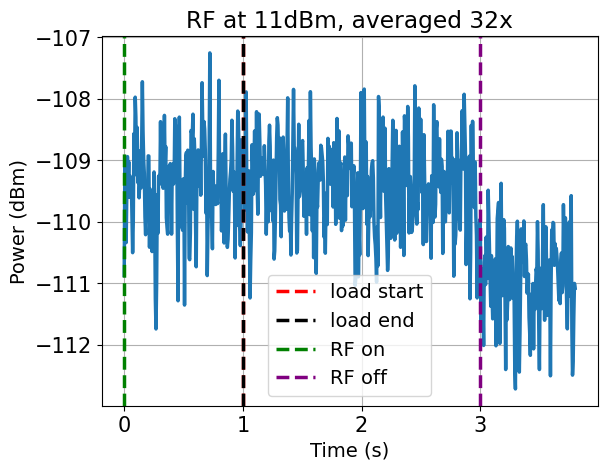

In [255]:
num_points = len(all_data[0])
t_axis = np.linspace(0, T_total, num_points) 
idx = np.where(t_axis < 3.8)
plot(t_axis[idx], np.mean(all_data, axis=0)[idx], xlabel='Time (s)', 
     ylabel='Power (dBm)', title=f'RF at 11dBm, averaged 32x')
plt.axvline(t_load_start, linestyle='--', color='r', label='load start') 
plt.axvline(t_load_end, linestyle='--', color='k', label='load end')
plt.axvline(t_RF_on, linestyle='--', color='g', label='RF on') 
plt.axvline(t_RF_off, linestyle='--', color='purple', label='RF off')
plt.legend()
plt.show()
PSU.set_voltage(1000)
beep()

In [257]:
PSU.output_off()